# DCHG_005 Multi-Dilated ResNet — Baseline
**11-channel archaeological site detection | 150×150**

This notebook trains the verified baseline dataset currently uploaded to Kaggle:

- TRAIN: **24,660** = 8,220 originals + 16,440 existing augmented variants
- VAL: **1,031** untouched
- TEST: **1,025** untouched
- Input: **11 × 150 × 150**
- No additional augmentation is applied in this baseline.
- Threshold is selected from VAL only and then frozen for TEST.


In [1]:
# 1 — Setup
import os, re, json, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve
)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
# 2 — Locate the Kaggle dataset automatically
INPUT_ROOT = Path("/kaggle/input")
EXPECTED = {"train": 24660, "val": 1031, "test": 1025}

def dataset_score(p):
    names={x.name.lower() for x in p.iterdir()}
    score=0
    score += 3 if "train" in names else 0
    score += 2 if ("val" in names or "validation" in names) else 0
    score += 2 if "test" in names else 0
    score += 1 if any("manifest" in n for n in names) else 0
    score += min(5, sum(1 for _ in p.rglob("*.npy"))/5000)
    return score

roots=[p for p in INPUT_ROOT.iterdir() if p.is_dir()]
if not roots: raise FileNotFoundError("No dataset found under /kaggle/input.")
DATA_ROOT=max(roots,key=dataset_score)

def locate(root,names):
    hits=[p for p in root.rglob("*") if p.is_dir() and p.name.lower() in names]
    return max(hits,key=lambda p:sum(1 for _ in p.glob("*.npy"))) if hits else None

TRAIN_DIR=locate(DATA_ROOT,{"train"})
VAL_DIR=locate(DATA_ROOT,{"val","validation"})
TEST_DIR=locate(DATA_ROOT,{"test"})
if not all([TRAIN_DIR,VAL_DIR,TEST_DIR]):
    raise FileNotFoundError(f"Could not locate train/val/test: {TRAIN_DIR}, {VAL_DIR}, {TEST_DIR}")

manifests=list(DATA_ROOT.rglob("*manifest*.csv"))
if not manifests: raise FileNotFoundError("No manifest CSV found.")
MANIFEST_PATH=next((p for p in manifests if "dchg005" in p.name.lower()),manifests[0])

print("DATA ROOT:",DATA_ROOT)
print("TRAIN:",TRAIN_DIR)
print("VAL:",VAL_DIR)
print("TEST:",TEST_DIR)
print("MANIFEST:",MANIFEST_PATH)


DATA ROOT: /kaggle/input/datasets
TRAIN: /kaggle/input/datasets/beginne/150dataset/train/train
VAL: /kaggle/input/datasets/beginne/150dataset/val/val
TEST: /kaggle/input/datasets/beginne/150dataset/test/test
MANIFEST: /kaggle/input/datasets/beginne/150dataset/dchg005_manifest.csv


In [4]:
# 3 — Verify file counts
files={
    "train":list(TRAIN_DIR.rglob("*.npy")),
    "val":list(VAL_DIR.rglob("*.npy")),
    "test":list(TEST_DIR.rglob("*.npy"))
}
for k,v in files.items():
    print(f"{k.upper():5s}: {len(v):,}")
    assert len(v)==EXPECTED[k], f"{k}: expected {EXPECTED[k]}, found {len(v)}"
print("PASS: exact verified file counts found.")


TRAIN: 24,660
VAL  : 1,031
TEST : 1,025
PASS: exact verified file counts found.


In [5]:
# 4 — Load and resolve manifest
manifest=pd.read_csv(MANIFEST_PATH)
print("Manifest:",manifest.shape)
print(manifest.columns.tolist())

def patch_num(s):
    m=re.search(r"patch[_-](\d+)",str(s),re.I)
    return int(m.group(1)) if m else None

by_name={f.name:f for fs in files.values() for f in fs}
by_split_id={}
for split,fs in files.items():
    for f in fs:
        pid=patch_num(f.name)
        if pid is not None: by_split_id.setdefault((split,pid),[]).append(f)

path_col=next((c for c in ["filepath","file_path","path","output_file","filename","file"] if c in manifest.columns),None)
if path_col is None: raise ValueError("No filepath column found in manifest.")
if "split" not in manifest.columns: raise ValueError("Manifest has no split column.")

manifest["split"]=manifest["split"].astype(str).str.lower().str.strip()
manifest["label"]=manifest["label"].apply(lambda x: int(str(x).strip().lower() in {"1","true","positive","pos"}) if isinstance(x,str) else int(x))

def resolve(row):
    split=row["split"]; raw=str(row[path_col])
    base=Path(raw.replace("\\","/")).name
    if base in by_name:
        p=by_name[base]
        # Ensure it belongs to the declared split.
        if p in files[split]: return p
    pid=patch_num(row.get("patch_id",""))
    if pid is None:
        try: pid=int(row.get("source_patch_id"))
        except: pid=None
    candidates=by_split_id.get((split,pid),[]) if pid is not None else []
    if not candidates: return None
    try: var=int(row.get("augmentation_variant")) if pd.notna(row.get("augmentation_variant")) else None
    except: var=None
    if var is not None:
        for p in candidates:
            if f"_aug{var}" in p.stem.lower(): return p
    originals=[p for p in candidates if "_aug" not in p.stem.lower()]
    return originals[0] if originals else candidates[0]

manifest["resolved_path"]=[str(p) if p else None for _,r in manifest.iterrows() for p in [resolve(r)]]
bad=manifest[manifest.resolved_path.isna()]
if len(bad): raise RuntimeError(f"{len(bad)} manifest rows could not be resolved.")
print("PASS: every manifest row resolves to an actual NPY.")


Manifest: (26716, 8)
['patch_id', 'source_patch_id', 'label', 'augmentation', 'augmentation_variant', 'split', 'filename', 'filepath']
PASS: every manifest row resolves to an actual NPY.


In [6]:
# 5 — Split checks
train_df=manifest[manifest.split=="train"].copy().reset_index(drop=True)
val_df=manifest[manifest.split.isin(["val","validation"])].copy().reset_index(drop=True)
test_df=manifest[manifest.split=="test"].copy().reset_index(drop=True)

for name,df,n in [("TRAIN",train_df,24660),("VAL",val_df,1031),("TEST",test_df,1025)]:
    print(f"{name}: {len(df):,} | pos={int(df.label.sum()):,} | neg={int((1-df.label).sum()):,}")
    assert len(df)==n

if "augmentation_variant" in train_df:
    print("\nTRAIN augmentation variants:")
    print(train_df.augmentation_variant.value_counts(dropna=False).sort_index())

# Source-ID contamination check when source_patch_id exists.
def source_ids(df):
    if "source_patch_id" in df.columns:
        vals=pd.to_numeric(df.source_patch_id,errors="coerce").dropna().astype(int)
        return set(vals)
    return {patch_num(x) for x in df.patch_id.astype(str) if patch_num(x) is not None}

tr_ids,va_ids,te_ids=source_ids(train_df),source_ids(val_df),source_ids(test_df)
print("\nTRAIN/VAL overlap:",len(tr_ids & va_ids))
print("TRAIN/TEST overlap:",len(tr_ids & te_ids))
assert not (tr_ids & va_ids) and not (tr_ids & te_ids)
print("PASS: no split contamination.")


TRAIN: 24,660 | pos=4,521 | neg=20,139
VAL: 1,031 | pos=189 | neg=842
TEST: 1,025 | pos=188 | neg=837

TRAIN augmentation variants:
augmentation_variant
0    8220
1    8220
2    8220
Name: count, dtype: int64

TRAIN/VAL overlap: 0
TRAIN/TEST overlap: 0
PASS: no split contamination.


In [7]:
# 6 — Dataset and DataLoaders
class DCHGDataset(Dataset):
    def __init__(self,df): self.df=df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        x=np.load(r.resolved_path,allow_pickle=False).astype(np.float32)
        if x.shape!=(11,150,150):
            raise RuntimeError(f"{r.resolved_path}: shape {x.shape}, expected (11,150,150)")
        if not np.isfinite(x).all(): raise RuntimeError(f"NaN/Inf: {r.resolved_path}")
        return torch.from_numpy(x),torch.tensor(float(r.label),dtype=torch.float32)

BATCH_SIZE=64
WORKERS=min(4,os.cpu_count() or 2)
kw=dict(batch_size=BATCH_SIZE,num_workers=WORKERS,pin_memory=DEVICE.type=="cuda",persistent_workers=WORKERS>0)

train_loader=DataLoader(DCHGDataset(train_df),shuffle=True,**kw)
val_loader=DataLoader(DCHGDataset(val_df),shuffle=False,**kw)
test_loader=DataLoader(DCHGDataset(test_df),shuffle=False,**kw)

x,y=next(iter(train_loader))
print("Batch:",x.shape,y.shape,"finite:",torch.isfinite(x).all().item())
assert x.shape==(BATCH_SIZE,11,150,150)


Batch: torch.Size([64, 11, 150, 150]) torch.Size([64]) finite: True


In [8]:
# 7 — Multi-Dilated ResNet
class ConvBNAct(nn.Module):
    def __init__(self,cin,cout,k=3,stride=1,dilation=1,act=True):
        super().__init__()
        pad=dilation*(k-1)//2
        self.net=nn.Sequential(
            nn.Conv2d(cin,cout,k,stride,pad,dilation,bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True) if act else nn.Identity()
        )
    def forward(self,x): return self.net(x)

class MultiDilatedBlock(nn.Module):
    def __init__(self,cin,cout,stride=1,dils=(1,2,4)):
        super().__init__()
        self.pre=ConvBNAct(cin,cout,3,stride,1)
        self.branches=nn.ModuleList([ConvBNAct(cout,cout,3,1,d) for d in dils])
        self.fuse=nn.Sequential(
            nn.Conv2d(cout*len(dils),cout,1,bias=False),
            nn.BatchNorm2d(cout)
        )
        self.short=nn.Sequential(
            nn.Conv2d(cin,cout,1,stride,bias=False),nn.BatchNorm2d(cout)
        ) if (cin!=cout or stride!=1) else nn.Identity()
        self.act=nn.ReLU(inplace=True)
    def forward(self,x):
        identity=self.short(x)
        z=self.pre(x)
        z=torch.cat([b(z) for b in self.branches],1)
        return self.act(self.fuse(z)+identity)

class MultiDilatedResNet(nn.Module):
    def __init__(self,in_channels=11,dropout=0.30):
        super().__init__()
        self.stem=nn.Sequential(
            nn.Conv2d(in_channels,32,5,padding=2,bias=False),
            nn.BatchNorm2d(32),nn.ReLU(inplace=True),
            nn.Conv2d(32,32,3,padding=1,bias=False),
            nn.BatchNorm2d(32),nn.ReLU(inplace=True))
        self.l1=MultiDilatedBlock(32,32,1)
        self.l2=MultiDilatedBlock(32,64,2)
        self.l3=MultiDilatedBlock(64,128,2)
        self.l4=MultiDilatedBlock(128,256,2)
        self.refine=MultiDilatedBlock(256,256,1)
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.drop=nn.Dropout(dropout)
        self.fc=nn.Linear(256,1)
        self.init_weights()
    def init_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Conv2d): nn.init.kaiming_normal_(m.weight,mode="fan_out",nonlinearity="relu")
            elif isinstance(m,nn.BatchNorm2d): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m,nn.Linear): nn.init.normal_(m.weight,0,0.01); nn.init.zeros_(m.bias)
    def forward(self,x):
        x=self.stem(x); x=self.l1(x); x=self.l2(x); x=self.l3(x); x=self.l4(x); x=self.refine(x)
        return self.fc(self.drop(self.pool(x).flatten(1))).squeeze(1)

model=MultiDilatedResNet().to(DEVICE)
params=sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")
with torch.no_grad():
    out=model(torch.randn(2,11,150,150,device=DEVICE))
print("Forward output:",out.shape)
assert out.shape==(2,)
print("PASS: model forward test.")


Parameters: 5,633,057
Forward output: torch.Size([2])
PASS: model forward test.


In [9]:
# 8 — Loss / optimizer / scheduler
pos=float(train_df.label.sum()); neg=float(len(train_df)-pos)
POS_WEIGHT=neg/max(pos,1)
criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT,dtype=torch.float32,device=DEVICE))

LR=3e-4
WEIGHT_DECAY=1e-4
EPOCHS=40
PATIENCE=8

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=3,min_lr=1e-6)

print("pos_weight:",POS_WEIGHT,"LR:",LR,"epochs:",EPOCHS)


pos_weight: 4.454545454545454 LR: 0.0003 epochs: 40


In [10]:
# 9 — Metrics
def metrics(y,p,t=0.5):
    pred=(p>=t).astype(int); y=np.asarray(y).astype(int)
    return {
        "accuracy":accuracy_score(y,pred),
        "precision":precision_score(y,pred,zero_division=0),
        "recall":recall_score(y,pred,zero_division=0),
        "f1":f1_score(y,pred,zero_division=0),
        "roc_auc":roc_auc_score(y,p) if len(np.unique(y))==2 else np.nan,
        "pr_auc":average_precision_score(y,p)
    }

def best_threshold(y,p):
    pr,re,th=precision_recall_curve(y,p)
    if len(th)==0:return .5
    f=2*pr[:-1]*re[:-1]/np.maximum(pr[:-1]+re[:-1],1e-12)
    return float(th[int(np.nanargmax(f))])


In [11]:
# 10 — Training functions
def train_epoch():
    model.train(); total=n=0
    for x,y in train_loader:
        x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda",dtype=torch.float16,enabled=DEVICE.type=="cuda"):
            loss=criterion(model(x),y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        total+=loss.item()*len(y); n+=len(y)
    return total/n

@torch.no_grad()
def predict(loader):
    model.eval(); ps=[]; ys=[]; total=n=0
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
        with torch.autocast(device_type="cuda",dtype=torch.float16,enabled=DEVICE.type=="cuda"):
            logits=model(x); loss=criterion(logits,y)
        total+=loss.item()*len(y); n+=len(y)
        ps.append(torch.sigmoid(logits).float().cpu().numpy()); ys.append(y.cpu().numpy())
    return total/n,np.concatenate(ys).astype(int),np.concatenate(ps)


In [12]:
# 11 — Train baseline
WORK=Path("/kaggle/working")
CKPT=WORK/"best_multidilated_resnet_baseline.pt"
hist=[]; best=-1; best_epoch=0; stale=0

for epoch in range(1,EPOCHS+1):
    tr=train_epoch()
    vl,vy,vp=predict(val_loader)
    vt=best_threshold(vy,vp)
    vm=metrics(vy,vp,vt)
    scheduler.step(vm["pr_auc"])
    lr=optimizer.param_groups[0]["lr"]
    rec={"epoch":epoch,"lr":lr,"train_loss":tr,"val_loss":vl,"threshold":vt,**vm}
    hist.append(rec)
    print(f"Epoch {epoch:02d} | LR={lr:.2e} | train={tr:.4f} | val={vl:.4f} | F1={vm['f1']:.4f} | P={vm['precision']:.4f} | R={vm['recall']:.4f} | PR-AUC={vm['pr_auc']:.4f} | ROC-AUC={vm['roc_auc']:.4f} | thr={vt:.3f}")
    if vm["pr_auc"]>best+1e-5:
        best=vm["pr_auc"]; best_epoch=epoch; stale=0
        torch.save({"model_state_dict":model.state_dict(),"epoch":epoch,"threshold":vt,"val_pr_auc":best,"config":{
            "architecture":"Multi-Dilated ResNet","input_shape":[11,150,150],"batch_size":BATCH_SIZE,
            "lr":LR,"weight_decay":WEIGHT_DECAY,"pos_weight":POS_WEIGHT,"seed":SEED}},CKPT)
        print("  BEST checkpoint saved.")
    else: stale+=1
    if stale>=PATIENCE:
        print("Early stopping."); break

history=pd.DataFrame(hist)
history.to_csv(WORK/"training_history.csv",index=False)
print("Best epoch:",best_epoch,"Best VAL PR-AUC:",best)


Epoch 01 | LR=3.00e-04 | train=1.0778 | val=1.0992 | F1=0.3565 | P=0.2262 | R=0.8413 | PR-AUC=0.2140 | ROC-AUC=0.5953 | thr=0.456
  BEST checkpoint saved.
Epoch 02 | LR=3.00e-04 | train=1.0646 | val=1.1193 | F1=0.3458 | P=0.2287 | R=0.7090 | PR-AUC=0.2316 | ROC-AUC=0.6013 | thr=0.457
  BEST checkpoint saved.
Epoch 03 | LR=3.00e-04 | train=1.0623 | val=1.1251 | F1=0.3415 | P=0.2343 | R=0.6296 | PR-AUC=0.2371 | ROC-AUC=0.6002 | thr=0.483
  BEST checkpoint saved.
Epoch 04 | LR=3.00e-04 | train=1.0697 | val=1.0927 | F1=0.3594 | P=0.2305 | R=0.8148 | PR-AUC=0.2650 | ROC-AUC=0.6302 | thr=0.441
  BEST checkpoint saved.
Epoch 05 | LR=3.00e-04 | train=1.0726 | val=1.1666 | F1=0.3581 | P=0.2275 | R=0.8413 | PR-AUC=0.2322 | ROC-AUC=0.6139 | thr=0.597
Epoch 06 | LR=3.00e-04 | train=1.0766 | val=1.1301 | F1=0.3580 | P=0.2290 | R=0.8201 | PR-AUC=0.2187 | ROC-AUC=0.5936 | thr=0.534
Epoch 07 | LR=3.00e-04 | train=1.0719 | val=1.8920 | F1=0.3133 | P=0.1860 | R=0.9947 | PR-AUC=0.2047 | ROC-AUC=0.5184 | 

In [13]:
# 12 — Best validation result
ckpt=torch.load(CKPT,map_location=DEVICE,weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
threshold=float(ckpt["threshold"])
_,vy,vp=predict(val_loader)
val_result=metrics(vy,vp,threshold)
print("BEST VALIDATION")
for k,v in val_result.items(): print(f"{k:10s}: {v:.6f}")
print("threshold :",threshold)


BEST VALIDATION
accuracy  : 0.467507
precision : 0.230539
recall    : 0.814815
f1        : 0.359393
roc_auc   : 0.630179
pr_auc    : 0.265011
threshold : 0.441162109375


In [14]:
# 13 — FINAL TEST (threshold frozen from VAL)
_,ty,tp=predict(test_loader)
test_result=metrics(ty,tp,threshold)
print("FINAL TEST")
for k,v in test_result.items(): print(f"{k:10s}: {v:.6f}")
cm=confusion_matrix(ty,(tp>=threshold).astype(int))
print("\nConfusion matrix [true rows, predicted columns]:\n",cm)


FINAL TEST
accuracy  : 0.501463
precision : 0.240770
recall    : 0.797872
f1        : 0.369914
roc_auc   : 0.655339
pr_auc    : 0.279119

Confusion matrix [true rows, predicted columns]:
 [[364 473]
 [ 38 150]]


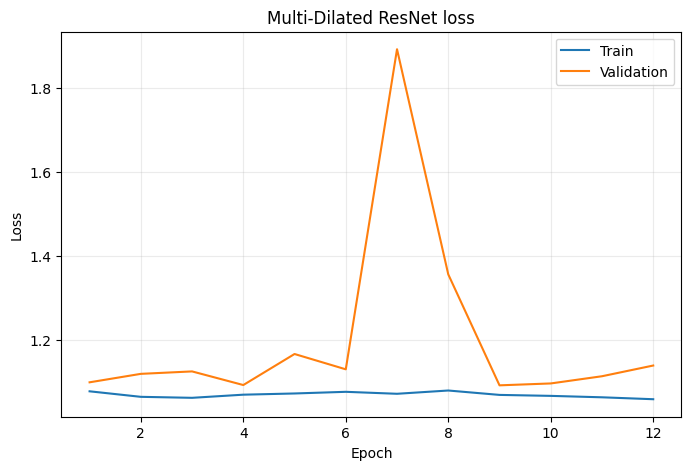

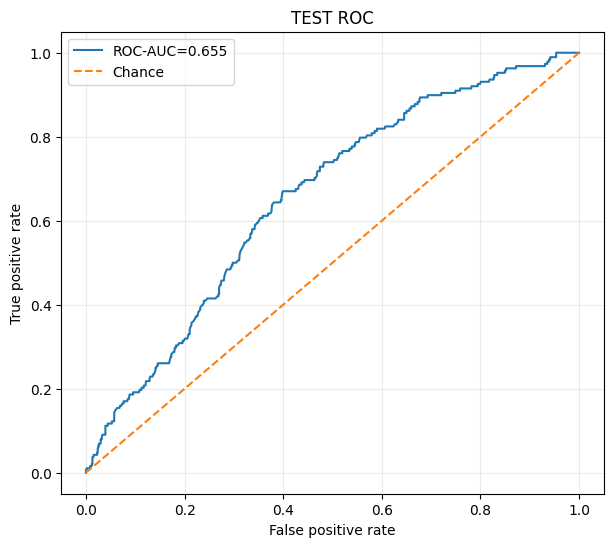

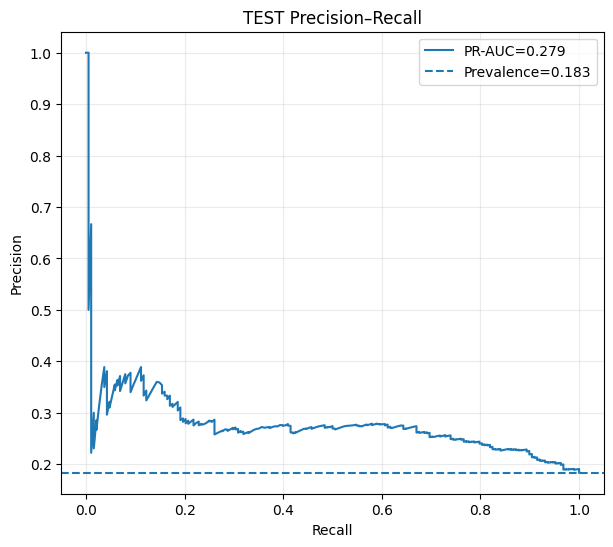

In [15]:
# 14 — Curves
h=history
plt.figure(figsize=(8,5)); plt.plot(h.epoch,h.train_loss,label="Train"); plt.plot(h.epoch,h.val_loss,label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Multi-Dilated ResNet loss"); plt.legend(); plt.grid(alpha=.25); plt.show()

fpr,tpr,_=roc_curve(ty,tp)
plt.figure(figsize=(7,6)); plt.plot(fpr,tpr,label=f"ROC-AUC={test_result['roc_auc']:.3f}"); plt.plot([0,1],[0,1],"--",label="Chance")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("TEST ROC"); plt.legend(); plt.grid(alpha=.25); plt.show()

pr,re,_=precision_recall_curve(ty,tp)
plt.figure(figsize=(7,6)); plt.plot(re,pr,label=f"PR-AUC={test_result['pr_auc']:.3f}"); plt.axhline(ty.mean(),linestyle="--",label=f"Prevalence={ty.mean():.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("TEST Precision–Recall"); plt.legend(); plt.grid(alpha=.25); plt.show()


In [16]:
# 15 — Save final experiment summary
summary={
    "experiment":"DCHG_005 Multi-Dilated ResNet baseline",
    "train_samples":len(train_df),"val_samples":len(val_df),"test_samples":len(test_df),
    "train_positives":int(train_df.label.sum()),"train_negatives":int((1-train_df.label).sum()),
    "best_epoch":best_epoch,"best_val_pr_auc":float(best),
    "validation_threshold":threshold,
    **{f"test_{k}":float(v) for k,v in test_result.items()},
    "parameters":int(params)
}
with open(WORK/"dchg005_baseline_results.json","w") as f: json.dump(summary,f,indent=2)
pd.DataFrame([summary]).to_csv(WORK/"dchg005_baseline_summary.csv",index=False)
print(json.dumps(summary,indent=2))
print("\nFiles saved in /kaggle/working:")
print(CKPT)
print(WORK/"training_history.csv")
print(WORK/"dchg005_baseline_results.json")
print(WORK/"dchg005_baseline_summary.csv")


{
  "experiment": "DCHG_005 Multi-Dilated ResNet baseline",
  "train_samples": 24660,
  "val_samples": 1031,
  "test_samples": 1025,
  "train_positives": 4521,
  "train_negatives": 20139,
  "best_epoch": 4,
  "best_val_pr_auc": 0.2650114223304894,
  "validation_threshold": 0.441162109375,
  "test_accuracy": 0.5014634146341463,
  "test_precision": 0.24077046548956663,
  "test_recall": 0.7978723404255319,
  "test_f1": 0.36991368680641185,
  "test_roc_auc": 0.6553388494877856,
  "test_pr_auc": 0.27911871380079306,
  "parameters": 5633057
}

Files saved in /kaggle/working:
/kaggle/working/best_multidilated_resnet_baseline.pt
/kaggle/working/training_history.csv
/kaggle/working/dchg005_baseline_results.json
/kaggle/working/dchg005_baseline_summary.csv


## Baseline complete

Keep the resulting checkpoint and metrics as **Experiment 1**.

Only after this experiment is finished should we create the larger augmentation experiment. The next comparison can then use the same architecture, split, optimizer policy, and evaluation procedure, changing only the TRAIN data.
